# 3. What the agent actually does

Tool calls, failures, and the sequences they form.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

DATA = Path.cwd().parent / "data"
sessions = pd.read_parquet(DATA / "sessions.parquet")
events = pd.read_parquet(DATA / "events.parquet")
print(f"{len(sessions):,} sessions, {len(events):,} events")

1,213 sessions, 181,406 events


In [2]:
from agent_telemetry.analysis import tools

frequency = tools.tool_frequency(events, top=15)
frequency

,tool_name,calls,events,sessions,share
0,Bash,23343,23343,788,0.5122
1,Read,15126,15121,968,0.3319
2,Edit,3007,3007,99,0.0660
3,Write,1178,1178,90,0.0258
4,TaskUpdate,547,547,139,0.0120
5,TaskCreate,337,337,140,0.0074
6,WebFetch,245,245,39,0.0054
7,WebSearch,240,240,46,0.0053
8,mcp__firecrawl__firecrawl_search,222,222,11,0.0049
9,AskUserQuestion,221,221,68,0.0048


Two tools account for most of the work. Bash alone is roughly half of all calls,
and Bash plus Read is about five sixths of them. Everything else is a long
tail.

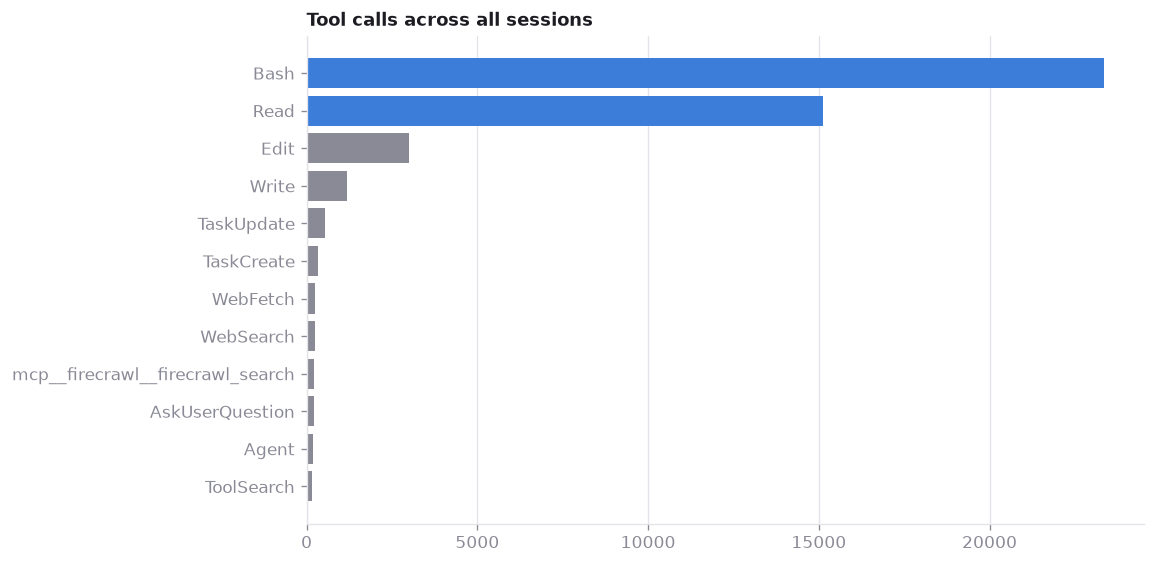

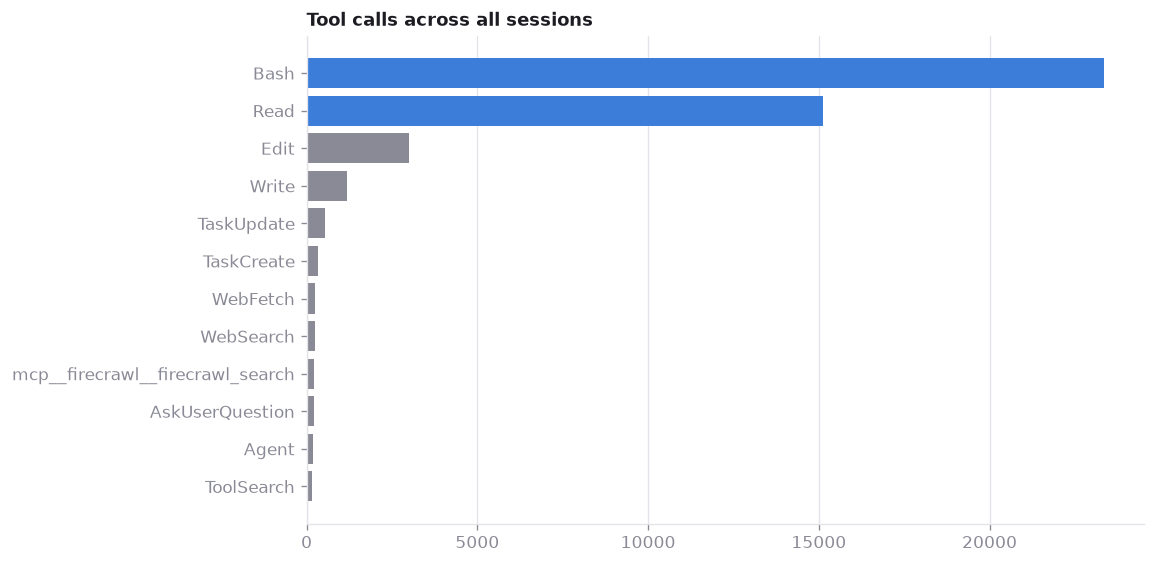

In [3]:
fig = None
from agent_telemetry import viz

fig = viz.bar(
    tools.tool_frequency(events, top=12),
    "tool_name",
    "calls",
    "Tool calls across all sessions",
    highlight=2,
)
fig

## Failure rate

Errors are attached to the tool result, so this counts results that came back
flagged as errors. A tool that reports failure in its output text instead is
invisible here, which means the real rate is a floor, not a ceiling.

In [4]:
tools.error_rates(events)

,results,errors,error_rate,median_session_error_rate,sessions_without_errors,sessions
0,45577,1186,0.026,0.0,753,1117


The overall rate is low and the median session has no failures at all, which
means errors concentrate in a minority of sessions rather than being spread
evenly.

In [5]:
by_session = events[events["tool_results"] > 0].groupby("session").agg(
    results=("tool_results", "sum"), errors=("tool_errors", "sum")
)
by_session["rate"] = by_session["errors"] / by_session["results"]
by_session["rate"].describe().round(3).to_frame("session error rate")

,session error rate
count,1117.000
mean,0.026
std,0.070
min,0.000
25%,0.000
50%,0.000
75%,0.023
max,1.000


## Sequences

Which tool follows which, within a session.

In [6]:
tools.tool_transitions(events, top=15)

,from_tool,to_tool,count
0,Bash,Bash,17864
1,Read,Read,10751
2,Bash,Read,3288
3,Read,Bash,2463
4,Edit,Bash,1205
5,Edit,Edit,1161
6,Read,Edit,1013
7,Bash,Edit,654
8,Bash,Write,453
9,Write,Bash,445


The dominant pairs are self transitions: Bash after Bash, Read after Read. That
is what batched exploration looks like from the outside, and it is the signature
of an agent gathering context before acting rather than alternating between
reading and editing.

In [7]:
tools.tools_per_session(sessions)

,metric,value
0,sessions,1213.0
1,sessions with tool calls,1117.0
2,median calls per session,10.0
3,median distinct tools per session,2.0
4,max calls in one session,1561.0
